<a href="https://colab.research.google.com/github/KaushikBose/Customer-Churn/blob/main/Customer_Churn_of_Power_Company.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the historical customer data
client_df = pd.read_csv('/content/client_data.csv')

# Load the historical pricing data
price_df = pd.read_csv('/content/price_data.csv')

## Historical Customer Data (`client_data.csv`)

In [2]:
print('First 5 rows of Historical Customer Data:')
display(client_df.head())

First 5 rows of Historical Customer Data:


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


## Historical Pricing Data (`price_data.csv`)

In [3]:
print('First 5 rows of Historical Pricing Data:')
display(price_df.head())

First 5 rows of Historical Pricing Data:


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## Data Types and Missing Values for Client Data

In [4]:
print('Client Data Info:')
client_df.info()

Client Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter

## Data Types and Missing Values for Pricing Data

In [5]:
print('Price Data Info:')
price_df.info()

Price Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


## Date Column Conversion

In [6]:
# Convert date columns to datetime objects in client_df
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])
client_df['date_modif_prod'] = pd.to_datetime(client_df['date_modif_prod'])
client_df['date_renewal'] = pd.to_datetime(client_df['date_renewal'])

# Convert date column to datetime object in price_df
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

print('Data types after date conversion for client_df:')
client_df[['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']].info()

print('\nData types after date conversion for price_df:')
price_df['price_date'].info()

Data types after date conversion for client_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date_activ       14606 non-null  datetime64[ns]
 1   date_end         14606 non-null  datetime64[ns]
 2   date_modif_prod  14606 non-null  datetime64[ns]
 3   date_renewal     14606 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 456.6 KB

Data types after date conversion for price_df:
<class 'pandas.core.series.Series'>
RangeIndex: 193002 entries, 0 to 193001
Series name: price_date
Non-Null Count   Dtype         
--------------   -----         
193002 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 1.5 MB


## Handling 'MISSING' values and checking for nulls

In [7]:
# Replace 'MISSING' string with actual NaN values in 'channel_sales' column
client_df['channel_sales'] = client_df['channel_sales'].replace('MISSING', pd.NA)

print('Missing values in client_df after replacing "MISSING":')
print(client_df.isnull().sum())

print('\nMissing values in price_df:')
print(price_df.isnull().sum())

Missing values in client_df after replacing "MISSING":
id                                   0
channel_sales                     3725
cons_12m                             0
cons_gas_12m                         0
cons_last_month                      0
date_activ                           0
date_end                             0
date_modif_prod                      0
date_renewal                         0
forecast_cons_12m                    0
forecast_cons_year                   0
forecast_discount_energy             0
forecast_meter_rent_12m              0
forecast_price_energy_off_peak       0
forecast_price_energy_peak           0
forecast_price_pow_off_peak          0
has_gas                              0
imp_cons                             0
margin_gross_pow_ele                 0
margin_net_pow_ele                   0
nb_prod_act                          0
net_margin                           0
num_years_antig                      0
origin_up                            0
pow_max  

## Descriptive Statistics for Client Data

In [8]:
print('Descriptive statistics for client_df (numerical columns):')
display(client_df.describe())

print('\nDescriptive statistics for client_df (categorical columns):')
display(client_df.describe(include='object'))

Descriptive statistics for client_df (numerical columns):


,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,...,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,...,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,...,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,...,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,...,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,...,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,...,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,...,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175



Descriptive statistics for client_df (categorical columns):


,id,channel_sales,has_gas,origin_up
count,14606,10881,14606,14606
unique,14606,7,2,6
top,563dde550fd624d7352f3de77c0cdfcd,foosdfpfkusacimwkcsosbicdxkicaua,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,11955,7097


## Descriptive Statistics for Pricing Data

In [9]:
print('Descriptive statistics for price_df (numerical columns):')
display(price_df.describe())

print('\nDescriptive statistics for price_df (categorical columns):')
display(price_df.describe(include='object'))

Descriptive statistics for price_df (numerical columns):


,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161216,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592



Descriptive statistics for price_df (categorical columns):


,id
count,193002
unique,16096
top,c18b6305122e4976739b8420d5b54ec5
freq,12


## Visualizing Distributions in `client_df` (Numerical Columns)

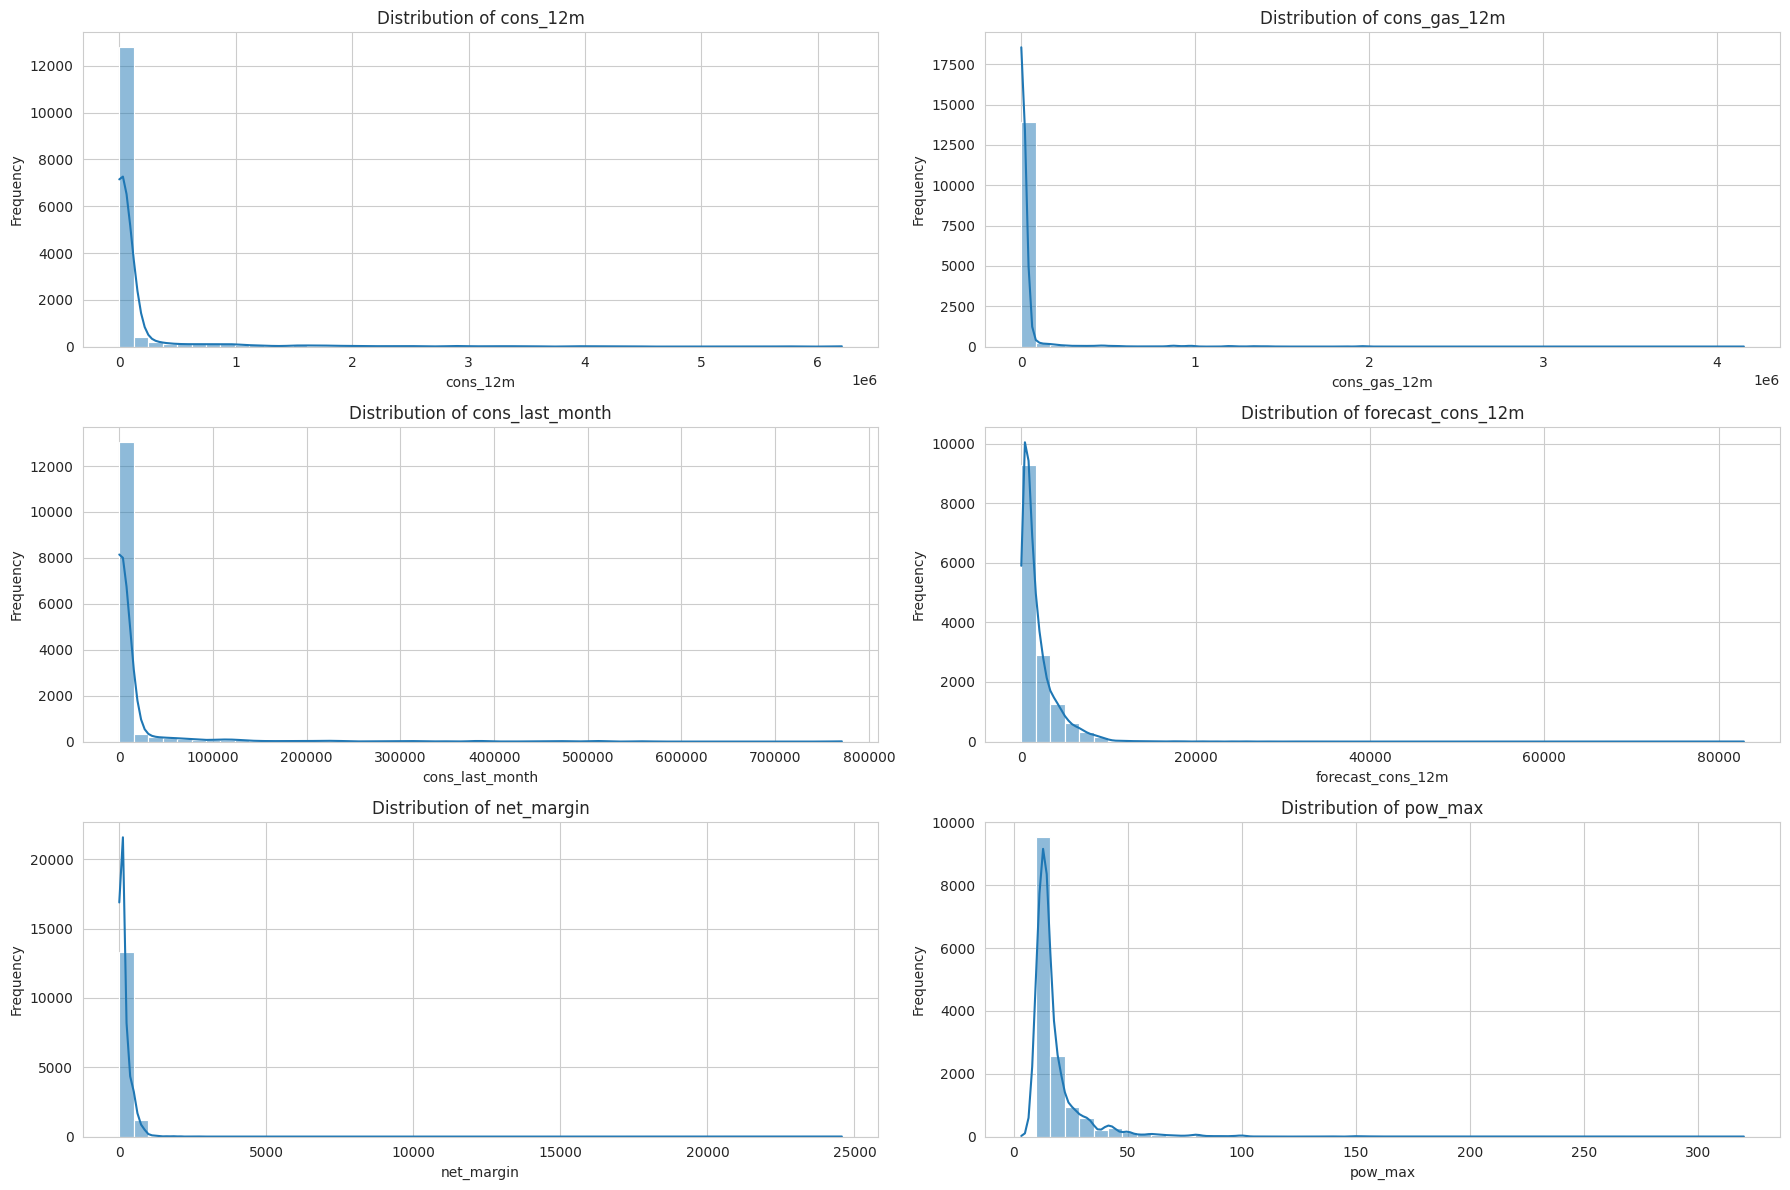

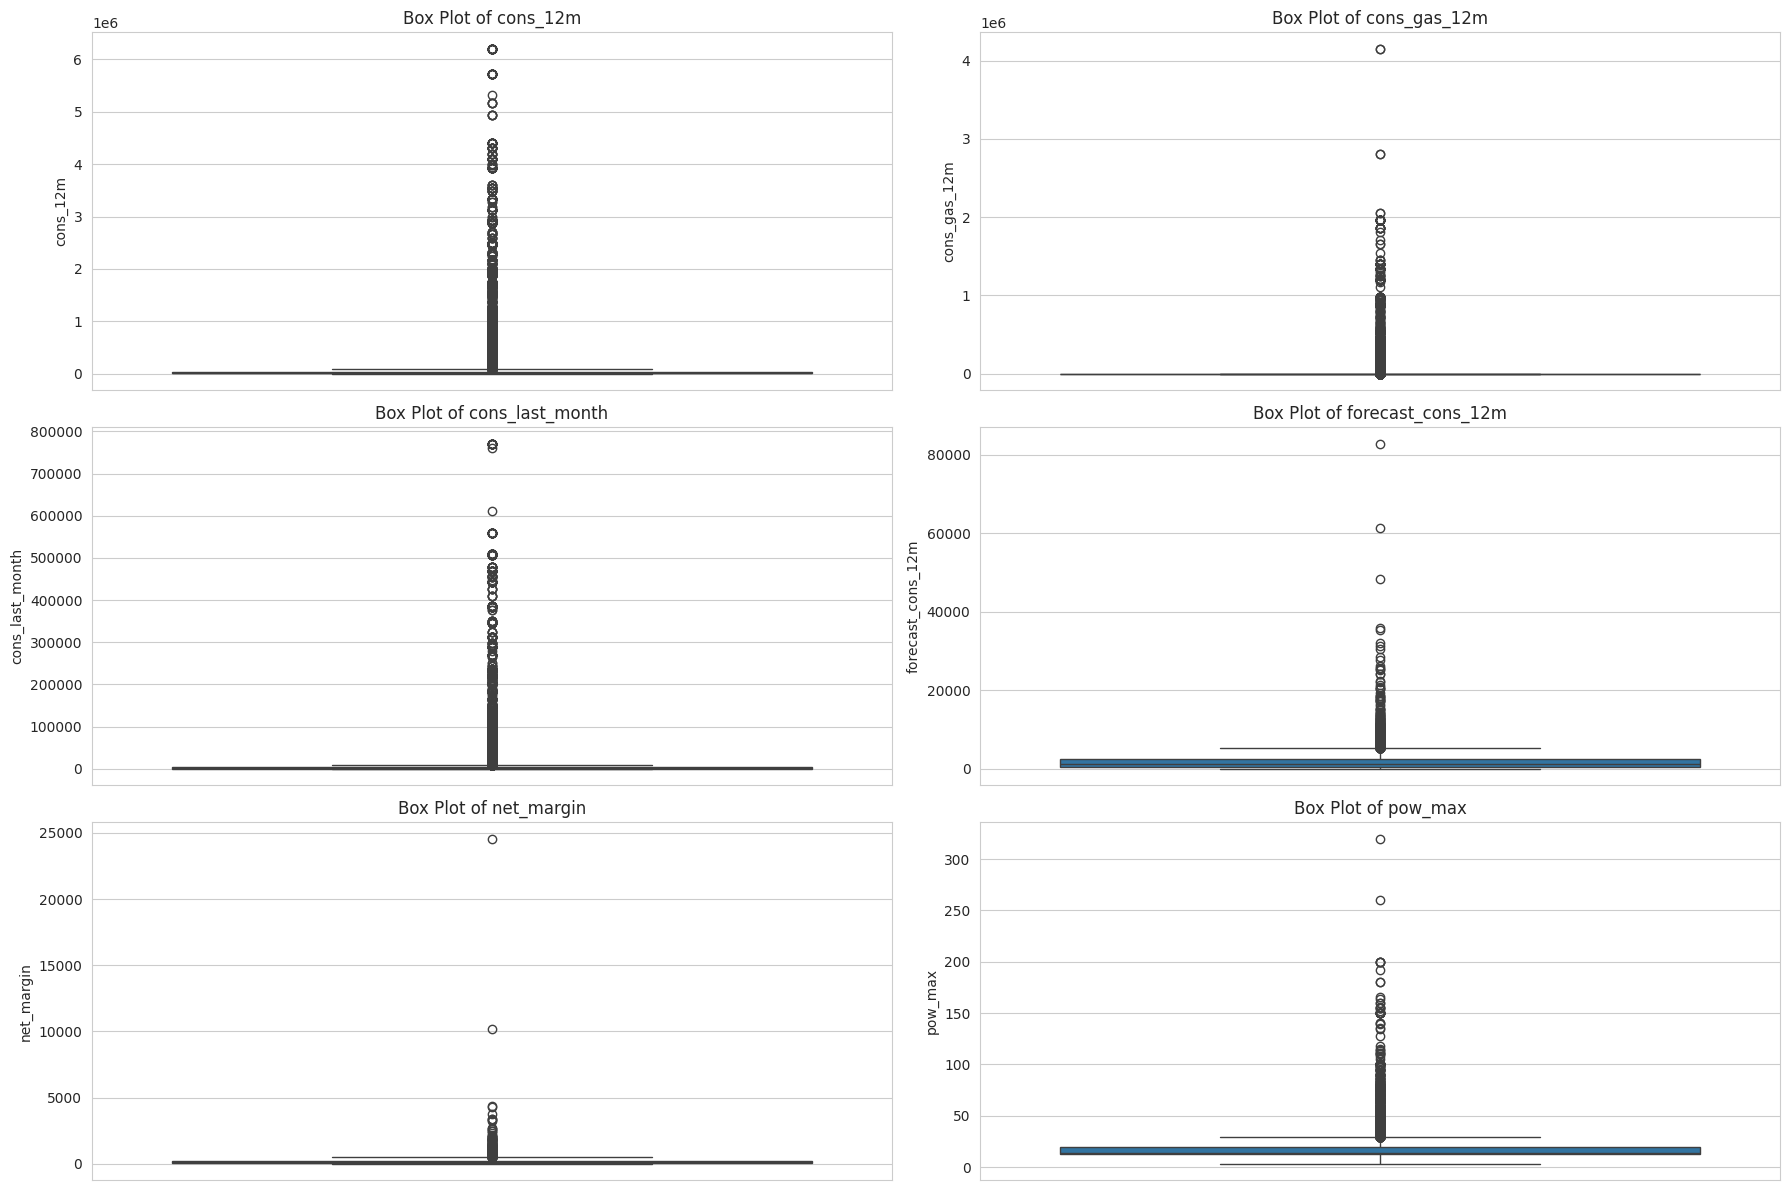

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Select numerical columns for distribution analysis
client_numerical_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'forecast_cons_12m',
    'net_margin',
    'pow_max'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(client_numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(client_df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for i, col in enumerate(client_numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=client_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Visualizing Distributions in `price_df` (Numerical Columns)

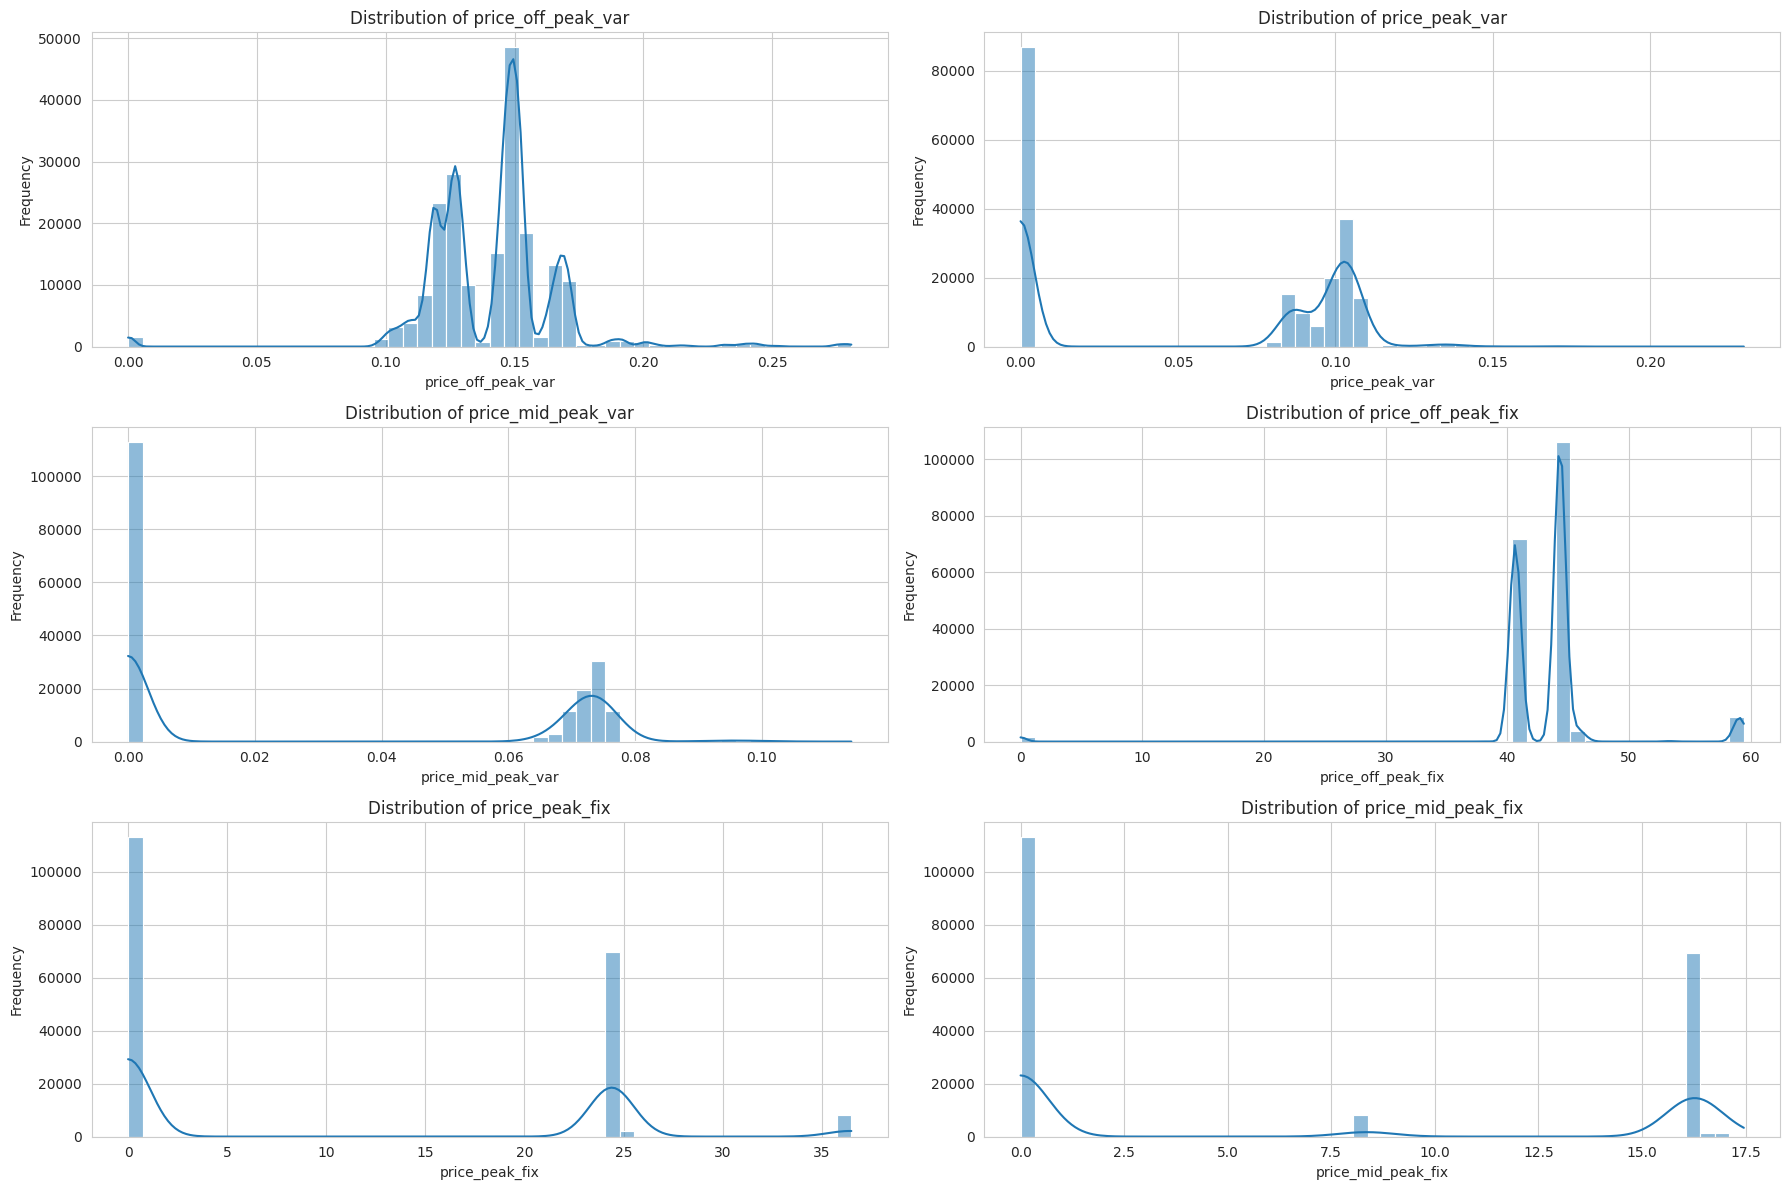

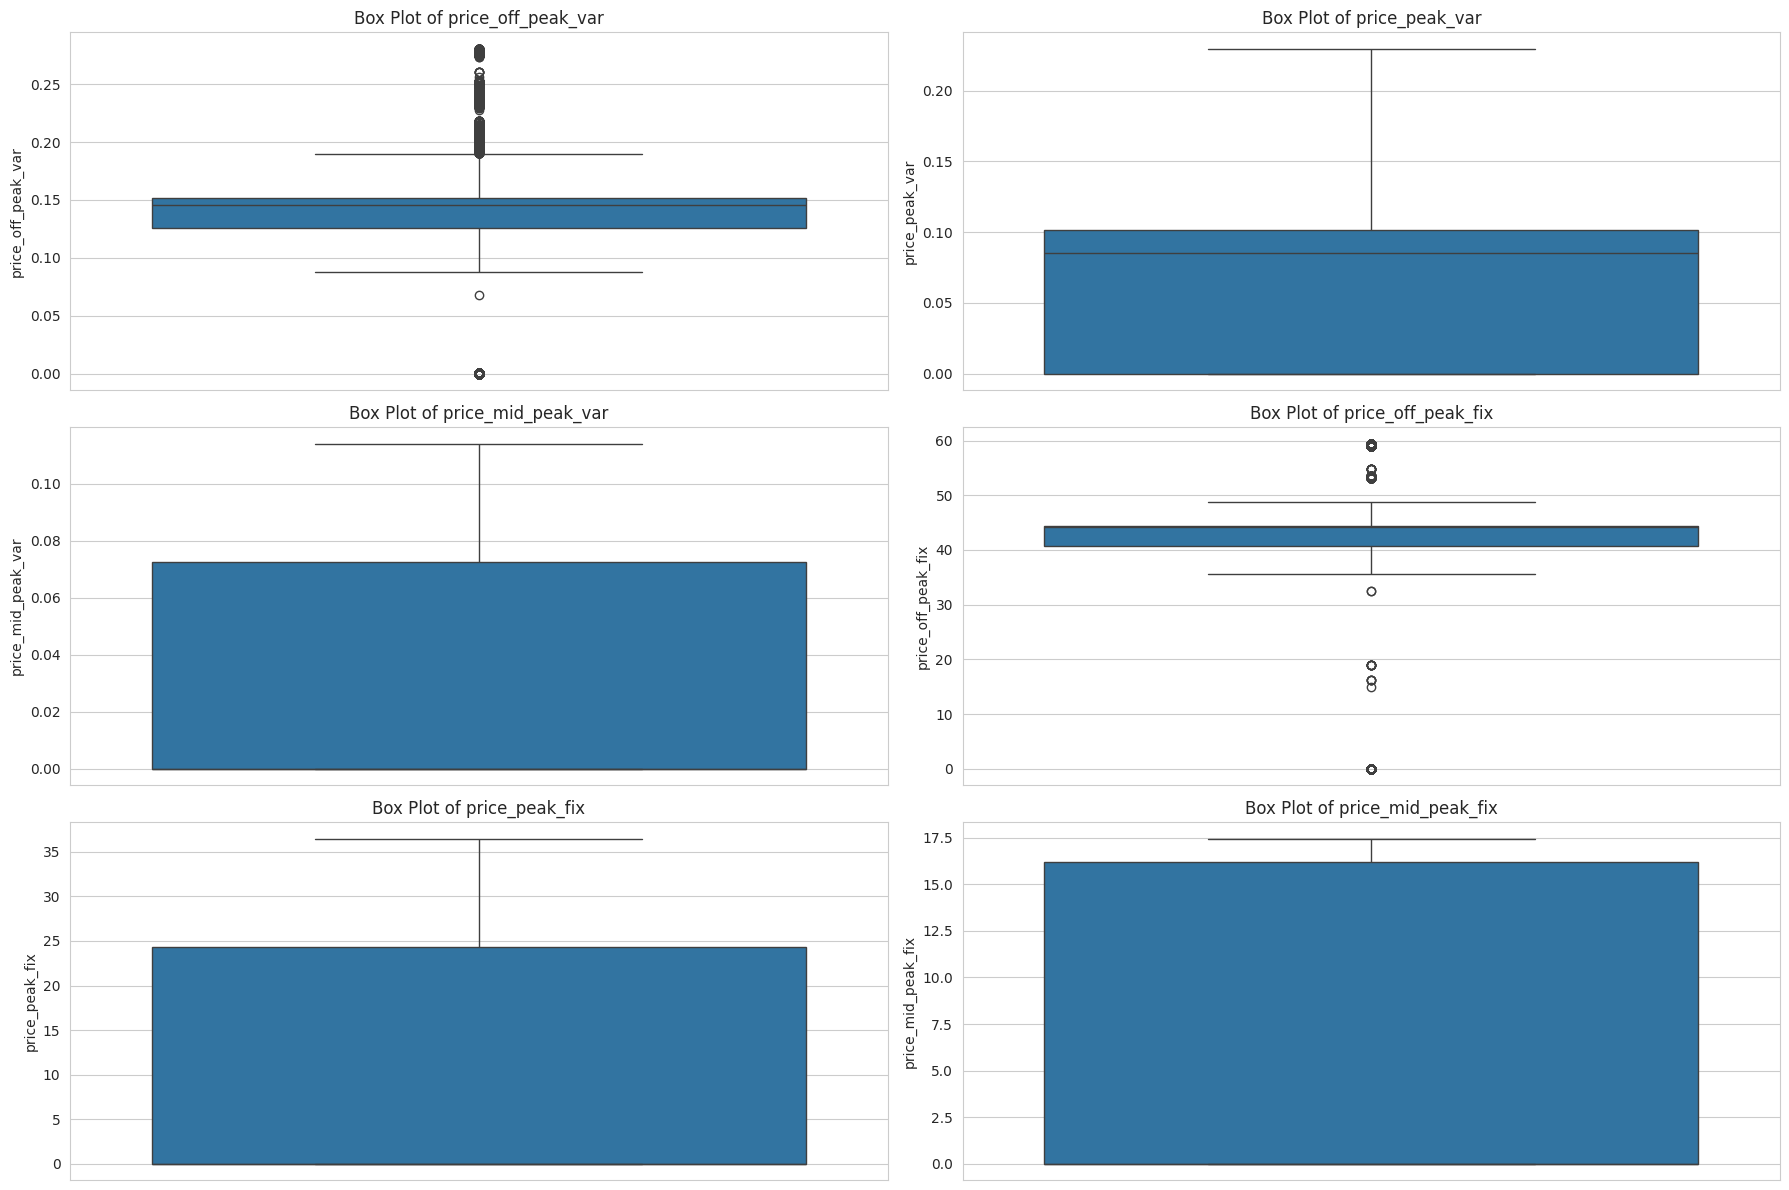

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# Select numerical columns for distribution analysis from price_df
price_numerical_cols = [
    'price_off_peak_var',
    'price_peak_var',
    'price_mid_peak_var',
    'price_off_peak_fix',
    'price_peak_fix',
    'price_mid_peak_fix'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(price_numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.histplot(price_df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for i, col in enumerate(price_numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(y=price_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Churn Variable Distribution

## Helper Functions for Plotting

In [18]:
def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

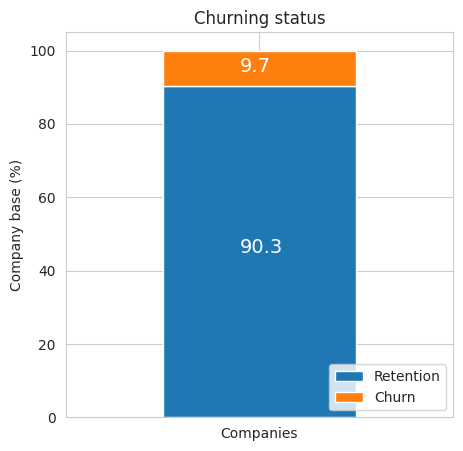

In [19]:
# Visualize the distribution of the churn variable
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100

plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

In [20]:
# Calculate the churn rate
churn_rate = client_df['churn'].value_counts(normalize=True) * 100
print(f"Churn Rate:\n{churn_rate}")

Churn Rate:
churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64


### Correlation Analysis between Churn and Numerical Features

In [21]:
numerical_cols_with_churn = client_df[client_numerical_cols + ['churn']]

# Calculate the correlation matrix
correlation_matrix = numerical_cols_with_churn.corr()

# Extract correlations with 'churn'
churn_correlations = correlation_matrix['churn'].drop('churn')

print('Correlation with Churn:')
print(churn_correlations)


Correlation with Churn:
cons_12m            -0.045968
cons_gas_12m        -0.037957
cons_last_month     -0.045284
forecast_cons_12m    0.012949
net_margin           0.041135
pow_max              0.030362
Name: churn, dtype: float64


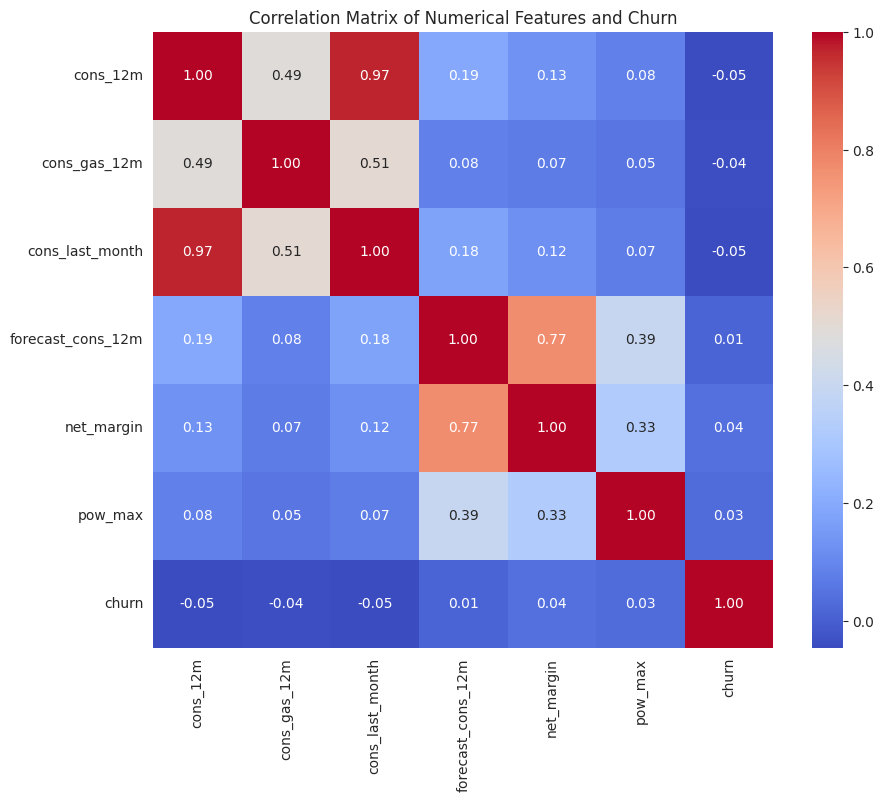

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Churn')
plt.show()

### Distribution of Categorical Features and their Relationship with Churn

/tmp/ipykernel_464/1733992582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=client_df, palette='viridis')


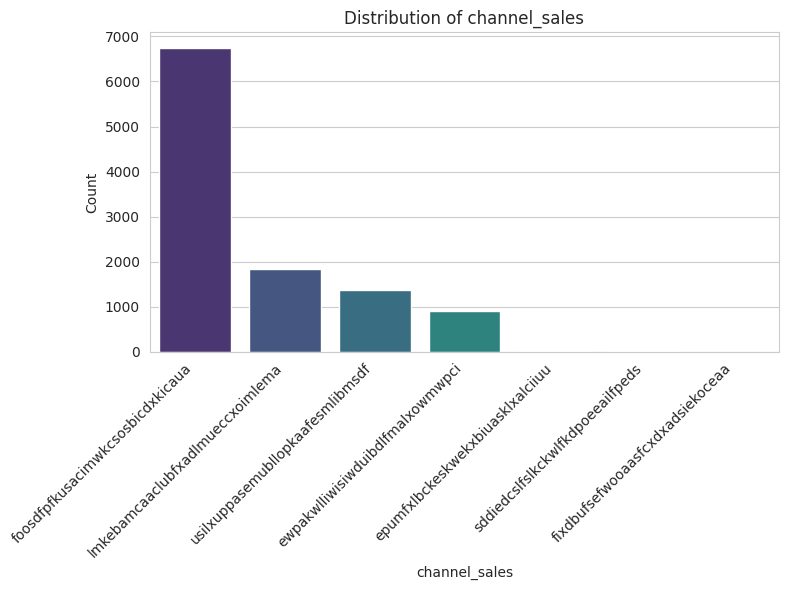

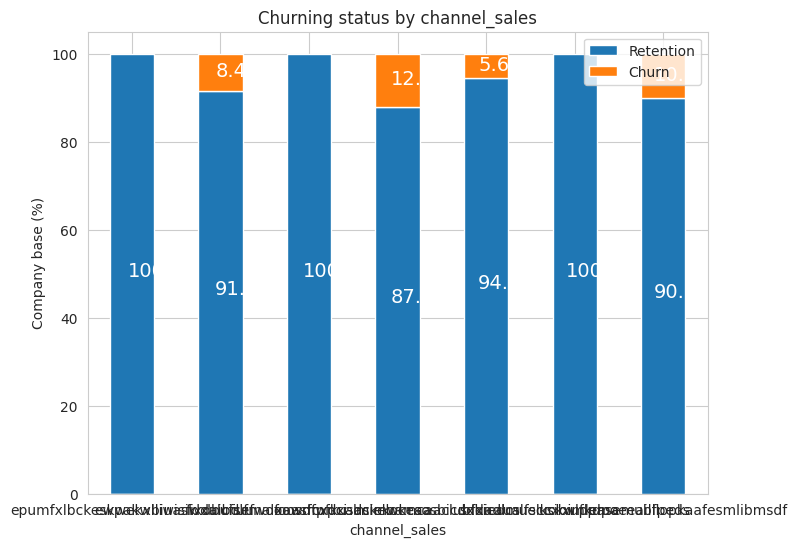

/tmp/ipykernel_464/1733992582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=client_df, palette='viridis')


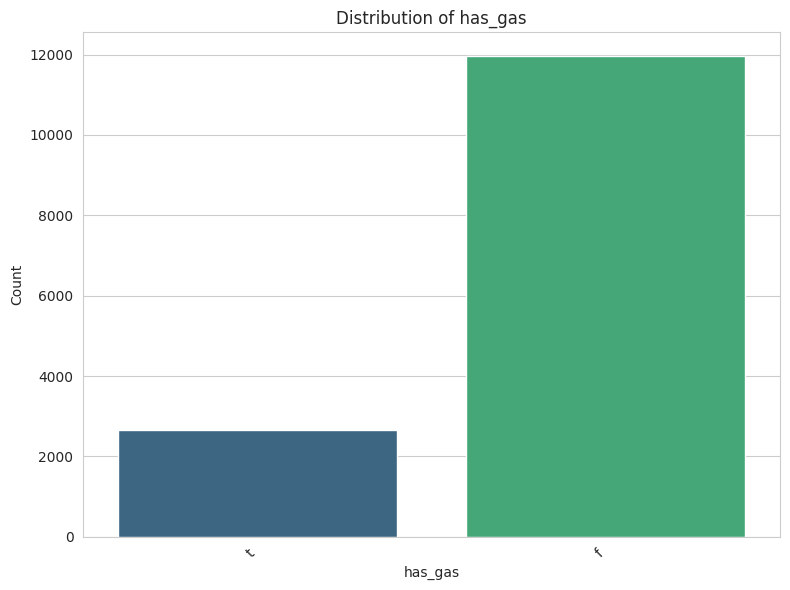

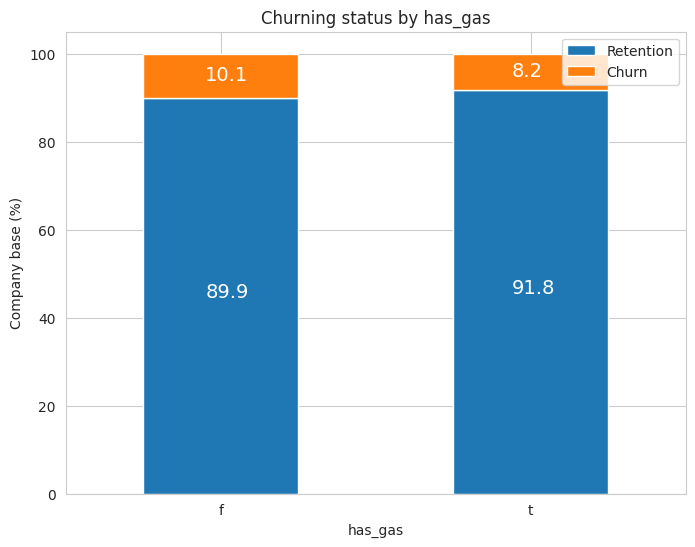

/tmp/ipykernel_464/1733992582.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=client_df, palette='viridis')


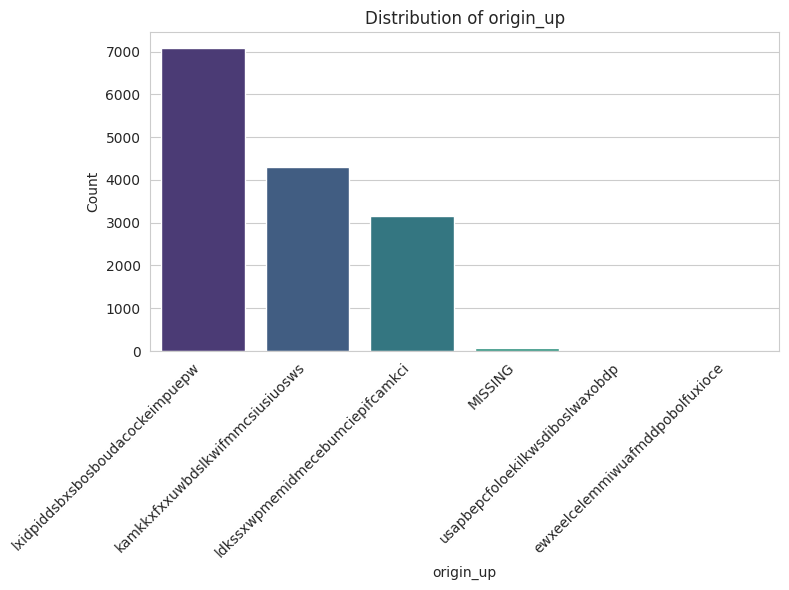

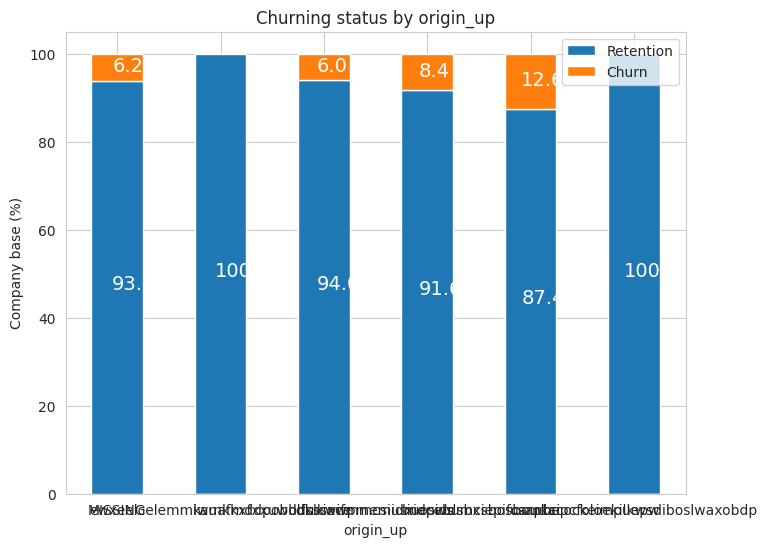

In [23]:
categorical_cols = ['channel_sales', 'has_gas', 'origin_up']

for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=col, data=client_df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Analyze relationship with churn using plot_stacked_bars
    if col != 'id': # 'id' is not a categorical feature for churn analysis
        churn_by_cat = client_df.groupby([col, 'churn']).size().unstack(fill_value=0)
        churn_by_cat_percentage = churn_by_cat.apply(lambda x: x / x.sum() * 100, axis=1)
        if not churn_by_cat_percentage.empty:
            plot_stacked_bars(churn_by_cat_percentage, f'Churning status by {col}', size_=(8, 6))
        else:
            print(f"No data to plot for churn analysis by {col}")